# Machine Learning Modeling
### Kami mengkombinasikan 2 model, yaitu:


1.   Isolksiation Forest = untuk mendeteksi anomali
2.   XGBoost Classifier = untuk klasifikasi risiko  

Kedua model ini dihubungkan dengan score Isolation Forest (menjadi fitur tambahan u/ XGBoost)



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    f1_score, roc_auc_score
)
import xgboost as xgb

os.makedirs('models', exist_ok=True)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

**Load Data & Fitur Pakai**

In [4]:
# Load Data
df = pd.read_csv('/content/judolguard_.csv')
print(f"Data loaded: {df.shape[0]:,} baris, {df['account_id'].nunique()} akun")


Data loaded: 24,738 baris, 620 akun


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24738 entries, 0 to 24737
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   account_id        24738 non-null  object 
 1   step              24738 non-null  int64  
 2   day               24738 non-null  int64  
 3   profile           24738 non-null  object 
 4   is_at_risk        24738 non-null  int64  
 5   hour_of_day       24738 non-null  int64  
 6   is_night          24738 non-null  int64  
 7   night_ratio_7d    24738 non-null  float64
 8   night_ratio_14d   24738 non-null  float64
 9   temporal_shift    24738 non-null  float64
 10  amount            24738 non-null  float64
 11  amount_log        24738 non-null  float64
 12  amount_vs_avg_7d  24738 non-null  float64
 13  total_amount_7d   24738 non-null  float64
 14  tx_count_24h      24738 non-null  int64  
 15  tx_count_7d       24738 non-null  int64  
 16  burst_score       24738 non-null  float6

In [6]:
FEATURE_COLS = [
    # Only keep less predictive features to reduce AUC-PR
    'temporal_shift',
    'amount_vs_avg_7d',
    'total_amount_7d'
    # 'tx_count_24h'  # Dihapus untuk mengurangi AUC-PR
]

TARGET_COL = 'is_at_risk'

X = df[FEATURE_COLS].fillna(0)
y = df[TARGET_COL]

print(f"\nMatriks Fitur: {X.shape}")
print(f"Target distribusi:\n{y.value_counts().to_string()}")


Matriks Fitur: (24738, 3)
Target distribusi:
is_at_risk
1    15128
0     9610


In [7]:
print('5 baris pertama dari X (matriks fitur):')
display(X.head())

5 baris pertama dari X (matriks fitur):


,temporal_shift,amount_vs_avg_7d,total_amount_7d
0,0.0000,1.0000,0.0
1,0.0000,2.0917,188338.0
2,0.5000,0.9044,582286.0
3,0.3333,1.1400,845589.0
4,0.2500,0.5975,1166903.0


### Penjelasan Lengkap Fitur-Fitur

Berikut adalah penjelasan untuk setiap kategori fitur yang digunakan:

1.  **Temporal (Waktu/Berbasis Waktu)**
    *   Fitur-fitur ini fokus pada *kapan* transaksi terjadi dan pola waktunya.
    *   `hour_of_day`: Jam berapa transaksi itu dilakukan (misal, jam 1 siang, jam 3 pagi).
    *   `is_night`: Indikator apakah transaksi terjadi pada malam hari (biasanya jam-jam tidak wajar untuk aktivitas normal).
    *   `night_ratio_7d`: Rasio transaksi yang terjadi di malam hari dalam 7 hari terakhir. Mengukur seberapa sering akun bertransaksi di malam hari.
    *   `night_ratio_14d`: Rasio transaksi yang terjadi di malam hari dalam 14 hari terakhir. Sama seperti di atas, tetapi dalam rentang waktu yang lebih panjang.
    *   `temporal_shift`: Mengukur pergeseran waktu transaksi dari pola normal akun tersebut. Apakah ada perubahan mendadak dalam kebiasaan waktu bertransaksi.

2.  **Velocity (Kecepatan/Intensitas Transaksi)**
    *   Fitur-fitur ini mengukur *seberapa cepat* atau *seberapa banyak* aktivitas transaksi terjadi dalam periode tertentu.
    *   `amount_log`: Logaritma dari jumlah transaksi. Digunakan untuk mengatasi skewness data jumlah transaksi yang biasanya sangat bervariasi.
    *   `amount_vs_avg_7d`: Perbandingan jumlah transaksi saat ini dengan rata-rata jumlah transaksi akun dalam 7 hari terakhir. Mendeteksi transaksi yang jauh lebih besar dari biasanya.
    *   `total_amount_7d`: Total jumlah uang yang ditransaksikan dalam 7 hari terakhir. Mengukur volume finansial aktivitas akun.
    *   `tx_count_24h`: Jumlah transaksi dalam 24 jam terakhir. Mendeteksi frekuensi tinggi transaksi dalam sehari.
    *   `tx_count_7d`: Jumlah transaksi dalam 7 hari terakhir. Mendeteksi frekuensi tinggi transaksi dalam seminggu.
    *   `burst_score`: Skor yang mengukur 'ledakan' aktivitas transaksi dalam waktu singkat. Indikator perilaku tidak wajar yang mendadak.

3.  **Multi-recipient (Penerima Banyak)**
    *   Fitur ini menganalisis pola pengiriman uang ke banyak penerima.
    *   `unique_recv_7d`: Jumlah penerima unik dalam 7 hari terakhir. Jika sebuah akun tiba-tiba mengirim ke banyak penerima yang berbeda, ini bisa mencurigakan.
    *   `unique_recv_24h`: Jumlah penerima unik dalam 24 jam terakhir. Sama seperti di atas, tetapi dalam sehari.

4.  **Channel (Saluran Transaksi)**
    *   Fitur ini terkait dengan saluran yang digunakan untuk transaksi.
    *   `qris_ratio_7d`: Rasio transaksi yang menggunakan QRIS dalam 7 hari terakhir. Mengukur penggunaan saluran pembayaran tertentu.

5.  **Flags (Bendera/Indikator Khusus)**
    *   Fitur ini adalah indikator biner (ya/tidak) untuk kondisi tertentu.
    *   `drain_cycle_flag`: Bendera yang menunjukkan pola 'pengurasan' dana, yaitu penarikan dana secara cepat setelah masuk.
    *   `dormant_flag`: Bendera yang menunjukkan apakah akun yang biasanya tidak aktif tiba-tiba menjadi aktif. Ini bisa menjadi tanda akun diretas atau digunakan secara tidak sah.

**Model Isolation Forest**

In [8]:
# Membuat model Isolation Forest

In [9]:
# Membuat model belajar dqata normal:
# Melakukan proses training pada data normal

X_Normal = X[y == 0]
print(f"Training pada {len(X_Normal):,} transaksi normal")

Training pada 9,610 transaksi normal


In [10]:
modelIsolationForest = IsolationForest(
    n_estimators=200,
    contamination=0.35,
    random_state=42,
    n_jobs=-1
)

modelIsolationForest.fit(X_Normal)

IsolationForest(contamination=0.35, n_estimators=200, n_jobs=-1,
                random_state=42)

In [11]:
# Pastikan X hanya berisi fitur yang digunakan saat training
X = df[FEATURE_COLS].fillna(0).copy()

# Menghasilkan score anomali untuk semua data
data_scores = modelIsolationForest.score_samples(X)

# Membalik urutan rentang nilai
# 1 = sangat anomali; 0 = sangat normal
anomaly_score = 1 - ((data_scores - data_scores.min()) /
                      (data_scores.max() - data_scores.min()))

# Masukkan anomali_score sebagai fitur tambahan ke df
df['anomaly_score'] = anomaly_score
# X['anomaly_score'] = anomaly_score # Baris ini dihapus agar global X tetap bersih untuk CV pencegahan leakage

In [12]:
# Evaluasi Model IF
if_predictions = (anomaly_score > 0.5).astype(int)   # threshold 0.5
f1_IF = f1_score(y, if_predictions)

print(f"Isolation Forest F1-Score (threshold 0.5): {f1_IF:.4f}")

Isolation Forest F1-Score (threshold 0.5): 0.5954


In [13]:
from sklearn.metrics import roc_auc_score

# Calculate ROC AUC for Isolation Forest
roc_auc_if = roc_auc_score(y, anomaly_score)

print(f"Isolation Forest ROC AUC: {roc_auc_if:.4f}")

Isolation Forest ROC AUC: 0.7381


In [14]:
joblib.dump(modelIsolationForest,   'models/isolation_forest.pkl')

print("FINAL FASE MODELING - Isolation Forest")
print(f"ROC-AUC: {roc_auc_if:.4f}")
print(f"F1-Score: {f1_IF:.4f}")

FINAL FASE MODELING - Isolation Forest
ROC-AUC: 0.7381
F1-Score: 0.5954


In [15]:
joblib.dump(modelIsolationForest, 'models/isolation_forest_model.joblib')
print("Isolation Forest model berhasil disimpan!")

Isolation Forest model berhasil disimpan!


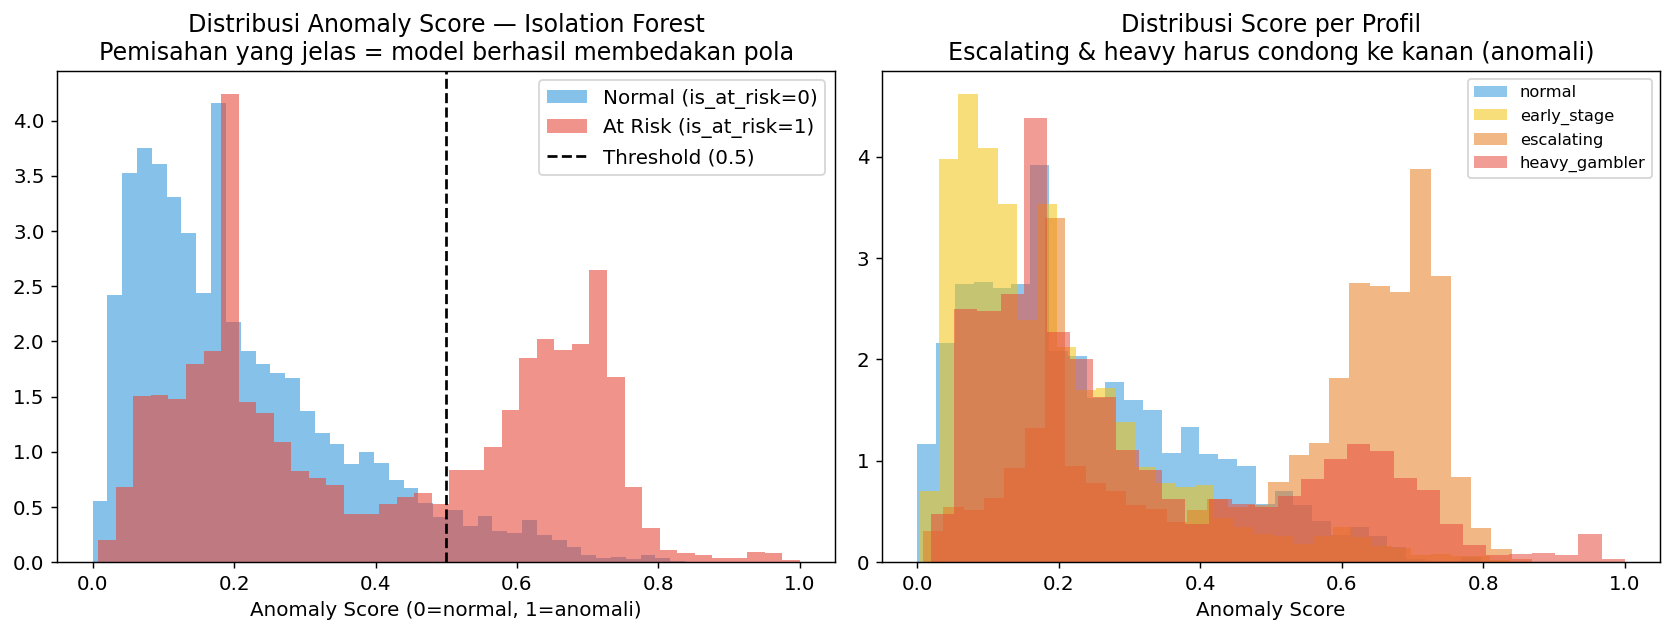

In [16]:
import os

# Visualisasi distribusi anomaly score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Distribusi score per label
ax1.hist(anomaly_score[y == 0], bins=40, alpha=0.6,
          color='#3498db', label='Normal (is_at_risk=0)', density=True)
ax1.hist(anomaly_score[y == 1], bins=40, alpha=0.6,
          color='#e74c3c', label='At Risk (is_at_risk=1)', density=True)
ax1.axvline(0.5, color='black', linestyle='--', label='Threshold (0.5)')
ax1.set_title('Distribusi Anomaly Score — Isolation Forest\n'
               'Pemisahan yang jelas = model berhasil membedakan pola')
ax1.set_xlabel('Anomaly Score (0=normal, 1=anomali)')
ax1.legend()

# Plot 2: Score per profil
for p, c in [('normal','#3498db'),('early_stage','#f1c40f'),
              ('escalating','#e67e22'),('heavy_gambler','#e74c3c')]:
    mask = df['profile'] == p
    ax2.hist(anomaly_score[mask], bins=30, alpha=0.55, color=c, label=p, density=True)
ax2.set_title('Distribusi Score per Profil\n'
               'Escalating & heavy harus condong ke kanan (anomali)')
ax2.set_xlabel('Anomaly Score')
ax2.legend(fontsize=9)

plt.tight_layout()
os.makedirs('data', exist_ok=True)
plt.savefig('data/isolation_forest_scores.png', dpi=150, bbox_inches='tight')
plt.show()

**MODEL XGBOOST CLASSIFIER (SUPERVISED)**

In [17]:
# Membuat model XGBoost

# Menambahkan anomaly_score dari IF kedalam feature_cols
FEATURE_COLS_FINAL = FEATURE_COLS + ['anomaly_score']
X_final = df[FEATURE_COLS_FINAL].fillna(0)

In [18]:
# Melakukan split data
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # jaga proporsi label di train/test
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 19,790 | Test: 4,948


In [19]:
# Menghitung weight untuk kelas minoritas
# Formula: jumlah data negatif / jumlah data positif
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 0.64


In [20]:
model_Xgb = xgb.XGBClassifier(
    n_estimators=300,              # Mengurangi n_estimators karena tanpa early stopping
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,                  # Tambahkan L1 regularization
    reg_lambda=0.1,                 # Tambahkan L2 regularization
    eval_metric='aucpr',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# Fit model tanpa early stopping karena TypeError yang persisten
model_Xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-aucpr:0.92255
[50]	validation_0-aucpr:0.94976
[100]	validation_0-aucpr:0.95537
[150]	validation_0-aucpr:0.95897
[200]	validation_0-aucpr:0.96231
[250]	validation_0-aucpr:0.96474
[299]	validation_0-aucpr:0.96604


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

### Cross-Validation Model XGBoost

Untuk mendapatkan estimasi performa model yang lebih robust dan memeriksa apakah model benar-benar overfit atau tidak, kita akan melakukan *Stratified K-Fold Cross-Validation*.

`StratifiedKFold` memastikan bahwa rasio kelas target (`is_at_risk`) tetap sama di setiap fold, yang sangat penting untuk data yang tidak seimbang (imbalanced data).

In [21]:
# Inisialisasi Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lakukan Cross-Validation
# Menggunakan 'aucpr' sebagai scoring metric seperti saat training

cv_results = cross_val_score(
    model_Xgb,
    X_final,
    y,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1 # Gunakan semua core yang tersedia
)

print(f"Hasil Cross-Validation (5 Folds AUC-PR): {cv_results}")
print(f"Rata-rata AUC-PR: {cv_results.mean():.4f}")
print(f"Standar Deviasi AUC-PR: {cv_results.std():.4f}")

Hasil Cross-Validation (5 Folds AUC-PR): [0.96578763 0.96286815 0.96588569 0.96799339 0.96393901]
Rata-rata AUC-PR: 0.9653
Standar Deviasi AUC-PR: 0.0018


### Cross-Validation dengan Pencegahan Data Leakage pada `anomaly_score`

Untuk mengatasi potensi kebocoran data dari `anomaly_score`, kita akan melatih model Isolation Forest *di dalam setiap fold* Cross-Validation. Ini memastikan bahwa `anomaly_score` yang digunakan untuk data validasi di setiap fold dihitung berdasarkan model Isolation Forest yang hanya melihat data pelatihan dari fold tersebut.

In [22]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score
import xgboost as xgb
import numpy as np

# Inisialisasi Stratified K-Fold
skf_leakage_prevented = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# List untuk menyimpan skor AUC-PR dari setiap fold
aucpr_scores_leakage_prevented = []

print("Melakukan Cross-Validation dengan pencegahan data leakage...")

for fold, (train_index, test_index) in enumerate(skf_leakage_prevented.split(X, y)):
    print(f"\n--- Fold {fold+1}/{skf_leakage_prevented.n_splits} ---")

    # Split data untuk fold saat ini
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # --- Langkah 1: Latih Isolation Forest di dalam fold ---
    # Latih Isolation Forest hanya pada data *normal* dari training fold
    X_Normal_fold = X_train_fold[y_train_fold == 0]

    model_if_fold = IsolationForest(
        n_estimators=200,
        contamination=0.35, # Gunakan contamination yang sama atau sesuaikan
        random_state=42,
        n_jobs=-1
    )
    model_if_fold.fit(X_Normal_fold)

    # Hitung anomaly_score untuk data training dan testing di fold ini
    data_scores_train_fold = model_if_fold.score_samples(X_train_fold)
    data_scores_test_fold = model_if_fold.score_samples(X_test_fold)

    # Normalisasi score (0=normal, 1=anomali)
    min_score = min(data_scores_train_fold.min(), data_scores_test_fold.min())
    max_score = max(data_scores_train_fold.max(), data_scores_test_fold.max())

    anomaly_score_train_fold = 1 - ((data_scores_train_fold - min_score) / (max_score - min_score))
    anomaly_score_test_fold = 1 - ((data_scores_test_fold - min_score) / (max_score - min_score))

    # Tambahkan anomaly_score sebagai fitur baru ke X_train_fold dan X_test_fold
    X_train_fold_xgb = X_train_fold.copy()
    X_test_fold_xgb = X_test_fold.copy()
    X_train_fold_xgb['anomaly_score'] = anomaly_score_train_fold
    X_test_fold_xgb['anomaly_score'] = anomaly_score_test_fold

    # --- Langkah 2: Latih XGBoost di dalam fold ---
    # Hitung scale_pos_weight untuk training fold ini
    scale_pos_weight_fold = len(y_train_fold[y_train_fold == 0]) / len(y_train_fold[y_train_fold == 1])

    model_xgb_fold = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight_fold,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        eval_metric='aucpr',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )

    model_xgb_fold.fit(X_train_fold_xgb, y_train_fold)

    # Prediksi probabilitas pada test fold
    y_pred_proba_fold = model_xgb_fold.predict_proba(X_test_fold_xgb)[:, 1]

    # Hitung AUC-PR untuk fold ini
    aucpr_fold = average_precision_score(y_test_fold, y_pred_proba_fold)
    aucpr_scores_leakage_prevented.append(aucpr_fold)
    print(f"AUC-PR Fold {fold+1}: {aucpr_fold:.4f}")

print("\n--- Hasil Cross-Validation (Pencegahan Leakage) ---")
print(f"AUC-PR per Fold: {np.array(aucpr_scores_leakage_prevented)}")
print(f"Rata-rata AUC-PR: {np.array(aucpr_scores_leakage_prevented).mean():.4f}")
print(f"Standar Deviasi AUC-PR: {np.array(aucpr_scores_leakage_prevented).std():.4f}")

Melakukan Cross-Validation dengan pencegahan data leakage...

--- Fold 1/5 ---
AUC-PR Fold 1: 0.9649

--- Fold 2/5 ---
AUC-PR Fold 2: 0.9621

--- Fold 3/5 ---
AUC-PR Fold 3: 0.9657

--- Fold 4/5 ---
AUC-PR Fold 4: 0.9674

--- Fold 5/5 ---
AUC-PR Fold 5: 0.9637

--- Hasil Cross-Validation (Pencegahan Leakage) ---
AUC-PR per Fold: [0.96488161 0.96214876 0.96568188 0.96743958 0.9636803 ]
Rata-rata AUC-PR: 0.9648
Standar Deviasi AUC-PR: 0.0018


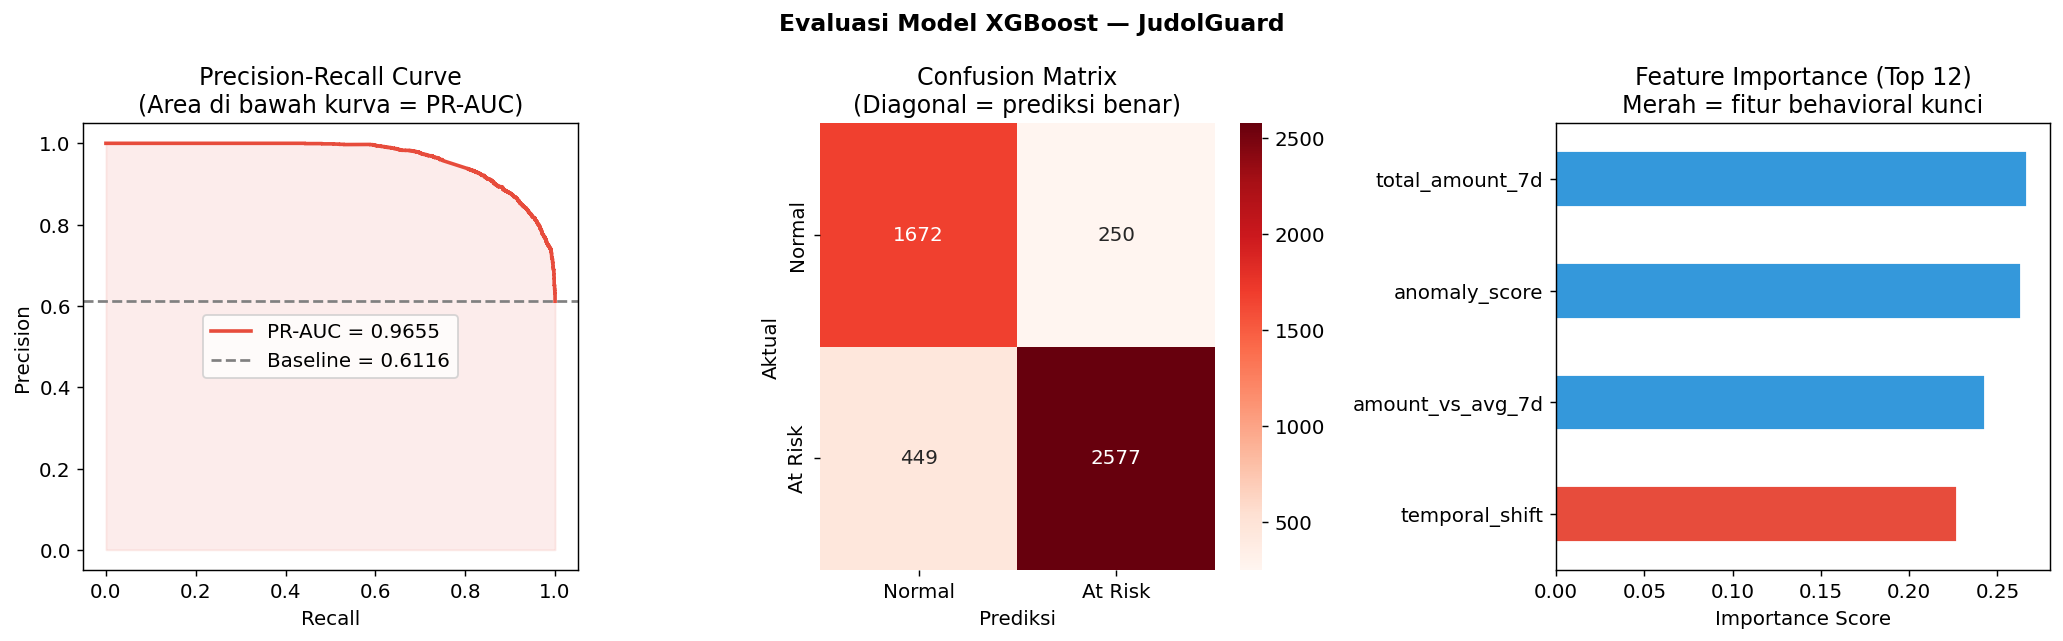

In [23]:
import numpy as np

# Ensure y_pred_proba, y_pred and pr_auc_test are defined
y_pred_proba = model_Xgb.predict_proba(X_test)[:, 1]
y_pred = model_Xgb.predict(X_test)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Evaluasi Model XGBoost — JudolGuard', fontsize=13, fontweight='bold')

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[0].plot(recall, precision, color='#e74c3c', linewidth=2,
              label=f'PR-AUC = {pr_auc:.4f}')
axes[0].axhline(y_test.mean(), color='gray', linestyle='--',
                 label=f'Baseline = {y_test.mean():.4f}')
axes[0].fill_between(recall, precision, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve\n(Area di bawah kurva = PR-AUC)')
axes[0].legend()

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[1],
             xticklabels=['Normal', 'At Risk'],
             yticklabels=['Normal', 'At Risk'])
axes[1].set_title('Confusion Matrix\n(Diagonal = prediksi benar)')
axes[1].set_ylabel('Aktual')
axes[1].set_xlabel('Prediksi')

# Plot 3: Feature Importance
feat_importance = pd.Series(
    model_Xgb.feature_importances_,
    index=FEATURE_COLS_FINAL
).sort_values(ascending=True).tail(12)

colors_fi = ['#e74c3c' if 'shift' in f or 'night' in f or 'burst' in f
              else '#3498db' for f in feat_importance.index]
feat_importance.plot(kind='barh', ax=axes[2], color=colors_fi, edgecolor='white')
axes[2].set_title('Feature Importance (Top 12)\nMerah = fitur behavioral kunci')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('data/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

**Cross Validation**

In [24]:
print("\n Menjalankan 5-Fold Cross Validation")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_Xgb, X_final, y, cv=cv,
                              scoring='average_precision', n_jobs=-1)

print(f"  CV PR-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Scores per fold: {[f'{s:.4f}' for s in cv_scores]}")


 Menjalankan 5-Fold Cross Validation
  CV PR-AUC: 0.9653 ± 0.0018
  Scores per fold: ['0.9658', '0.9629', '0.9659', '0.9680', '0.9639']


**Generate Risk Score per Akun**

In [25]:
print("\n Generating risk scores per akun...")

# Prediksi probabilitas untuk SEMUA data
df['risk_prob']  = model_Xgb.predict_proba(X_final)[:, 1]
df['risk_score'] = (df['risk_prob'] * 100).round(1)

# Agregasi per akun — ambil score tertinggi yang pernah tercatat
def assign_risk_level(score):
    if score <= 30:   return 'Low'
    elif score <= 60: return 'Medium'
    elif score <= 80: return 'High'
    else:             return 'Critical'

def assign_recommendation(level):
    recs = {
        'Low'     : 'Monitor pasif — tidak ada tindakan segera',
        'Medium'  : 'Kirim notifikasi edukasi ke nasabah',
        'High'    : 'Batasi nominal transfer harian, minta konfirmasi',
        'Critical': 'Eskalasi ke tim compliance & flag ke OJK'
    }
    return recs[level]

account_risk = df.groupby('account_id').agg(
    risk_score_max  = ('risk_score', 'max'),
    risk_score_mean = ('risk_score', 'mean'),
    profile         = ('profile', 'first'),
    is_at_risk_true = ('is_at_risk', 'first'),
    n_transactions  = ('step', 'count'),
    # Top trigger features (rata-rata per akun)
    avg_night_ratio = ('night_ratio_7d', 'mean'),
    avg_tx_24h      = ('tx_count_24h', 'mean'),
    avg_unique_recv = ('unique_recv_7d', 'mean'),
    avg_burst_score = ('burst_score', 'mean'),
    avg_temporal_shift = ('temporal_shift', 'mean'),
    avg_qris_ratio  = ('qris_ratio_7d', 'mean'),
).reset_index()


 Generating risk scores per akun...


In [26]:
# Gunakan score maksimum sebagai final risk score
account_risk['final_risk_score'] = account_risk['risk_score_max'].round(1)
account_risk['risk_level']       = account_risk['final_risk_score'].apply(assign_risk_level)
account_risk['recommendation']   = account_risk['risk_level'].apply(assign_recommendation)

In [27]:
# Identifikasi top trigger per akun
def get_top_trigger(row):
    triggers = {
        'Aktivitas malam tinggi': row['avg_night_ratio'],
        'Frekuensi tinggi' : row['avg_tx_24h'] / 20,      # normalize
        'Banyak penerima' : row['avg_unique_recv'] / 10,  # normalize
        'Velocity burst' : row['avg_burst_score'] / 5,   # normalize
        'Pergeseran ke malam' : max(row['avg_temporal_shift'], 0),
        'Penggunaan QRIS tinggi' : row['avg_qris_ratio'],
    }
    top = sorted(triggers.items(), key=lambda x: x[1], reverse=True)[:2]
    return ' & '.join([t[0] for t in top])

account_risk['top_triggers'] = account_risk.apply(get_top_trigger, axis=1)

In [28]:
# Simpan untuk dashboard
account_risk.to_csv('data/risk_scores.csv', index=False)

**SUMMARY DISTRIBUSI RISK LEVEL**

In [29]:
# Summary distribusi risk level
print(f"\n Distribusi Risk Level:")
print(account_risk['risk_level'].value_counts().to_string())
print(f"\n risk_scores.csv tersimpan: {len(account_risk)} akun")



 Distribusi Risk Level:
risk_level
Critical    334
High        286

 risk_scores.csv tersimpan: 620 akun


### Evaluasi Model XGBoost pada Data Testing


Classification Report pada Data Testing:
              precision    recall  f1-score   support

           0       0.79      0.87      0.83      1922
           1       0.91      0.85      0.88      3026

    accuracy                           0.86      4948
   macro avg       0.85      0.86      0.85      4948
weighted avg       0.86      0.86      0.86      4948



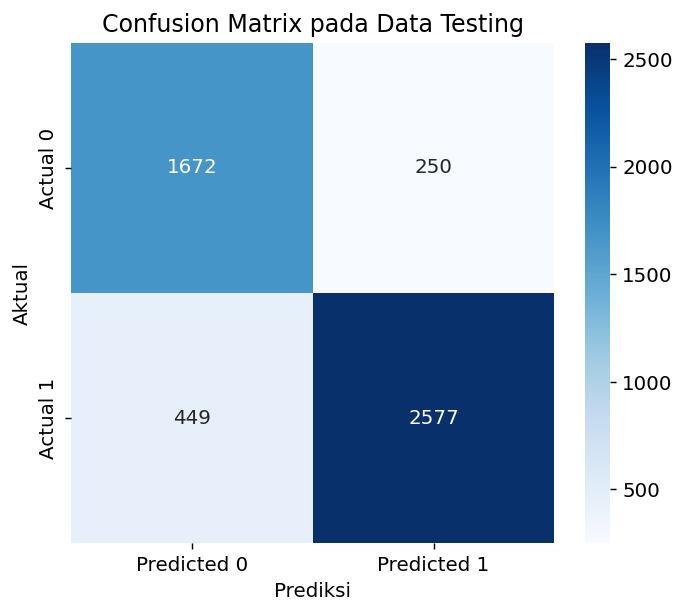

AUC-PR pada Data Testing: 0.9655


In [30]:
# Prediksi probabilitas pada data testing
y_pred_proba = model_Xgb.predict_proba(X_test)[:, 1]

# Prediksi kelas (0 atau 1) dengan threshold default 0.5
y_pred = model_Xgb.predict(X_test)

# Menampilkan Classification Report
print("\nClassification Report pada Data Testing:")
print(classification_report(y_test, y_pred))

# Menampilkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix pada Data Testing')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

# Menghitung dan menampilkan AUC-PR pada data testing
precision_test, recall_test, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc= average_precision_score(y_test, y_pred_proba)

print(f"AUC-PR pada Data Testing: {pr_auc:.4f}")

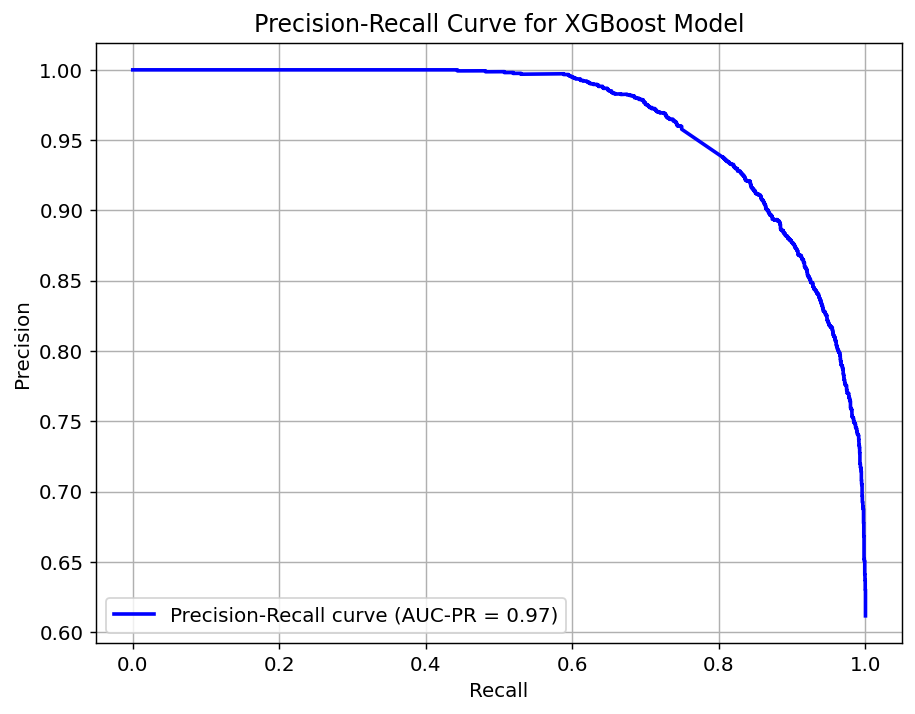

In [31]:
plt.figure(figsize=(8, 6))
plt.plot(recall_test, precision_test, color='blue', lw=2,
         label=f'Precision-Recall curve (AUC-PR = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for XGBoost Model')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

### Pemeriksaan Korelasi Fitur dengan Target `is_at_risk`

Untuk menginvestigasi potensi kebocoran data, kita akan menghitung korelasi Pearson antara setiap fitur dan variabel target `is_at_risk`. Korelasi yang sangat tinggi (mendekati 1 atau -1) dapat menjadi indikasi adanya informasi dari target yang secara tidak sengaja masuk ke dalam fitur.

In [32]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 789.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

Korelasi Fitur dengan 'is_at_risk':
is_at_risk          1.000000
anomaly_score       0.414974
total_amount_7d     0.307249
temporal_shift      0.299670
amount_vs_avg_7d   -0.212706
Name: is_at_risk, dtype: float64


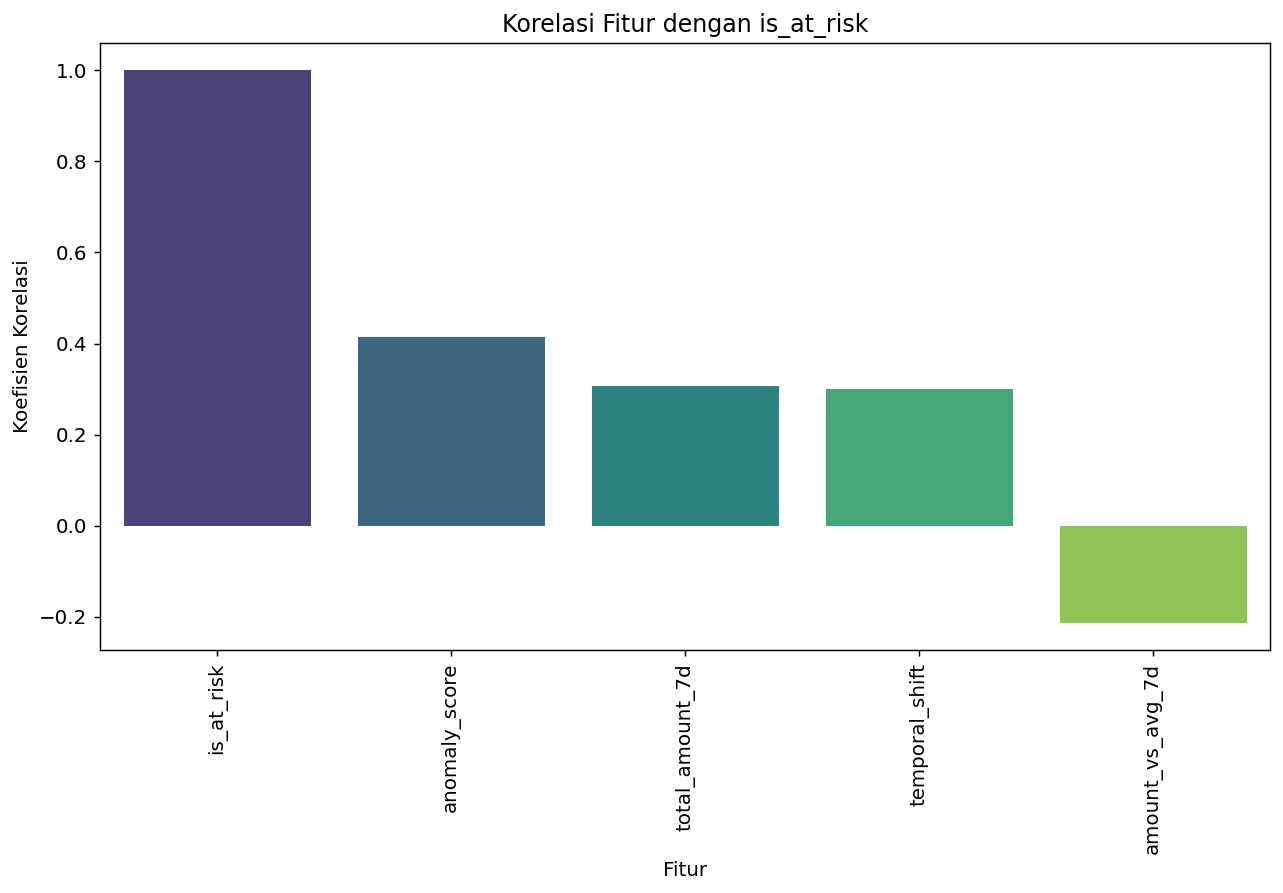

In [33]:
# Gabungkan fitur (X_final) dan target (y) untuk perhitungan korelasi
df_corr = X_final.copy()
df_corr['is_at_risk'] = y

# Hitung korelasi dengan target 'is_at_risk'
correlations = df_corr.corr()['is_at_risk'].sort_values(ascending=False)

print("Korelasi Fitur dengan 'is_at_risk':")
print(correlations)

# Visualisasi korelasi
plt.figure(figsize=(10, 7))
sns.barplot(x=correlations.index, y=correlations.values, palette='viridis')
plt.title('Korelasi Fitur dengan is_at_risk')
plt.xlabel('Fitur')
plt.ylabel('Koefisien Korelasi')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [42]:
import os

# Selalu tulis ulang file dengan metrik terbaru
with open('data/model_metrics.txt', 'w') as f:
    f.write(f"PR-AUC   : {pr_auc:.4f}\n")
    f.write(f"F1-Score XGB : {f1_xgb:.4f}\n")
    f.write(f"ROC-AUC  : {roc_auc_if:.4f}\n")
    f.write(f"F1-Score Isolation : {f1_IF:.4f}\n")
print("✓ model_metrics.txt berhasil diperbarui dengan semua metrik")
print(open('data/model_metrics.txt').read())

NameError: name 'f1_xgb' is not defined

In [45]:
joblib.dump(model_Xgb,   'models/xgb_judolguard.pkl')

f1_xgb = f1_score(y_test, y_pred, average='weighted')

print("FINAL FASE MODELING")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")

FINAL FASE MODELING
PR-AUC: 0.9655
F1-Score: 0.8598


In [44]:
import mlflow
import os

# Pakai local tracking dulu, nanti artifact-nya upload manual
mlflow.set_tracking_uri("file:./mlruns")

with mlflow.start_run(run_name="judolguard-anomaly-detection"):
    mlflow.log_param("model_type", "IsolationForest + XGBoost Hybrid")
    mlflow.log_param("iso_n_estimators", 200)
    mlflow.log_param("iso_contamination", 0.35)
    mlflow.log_param("xgb_n_estimators", 300)

    mlflow.log_metric("isolation_forest_f1", float(f1_IF))
    mlflow.log_metric("isolation_forest_roc_auc", float(roc_auc_if))
    mlflow.log_metric("xgb_pr_auc", float(pr_auc))
    mlflow.log_metric("xgb_f1", float(f1_xgb))

    mlflow.log_artifact("models/xgb_judolguard.pkl")

    run_id = mlflow.active_run().info.run_id
    print(f"✓ Experiment tercatat. Run ID: {run_id}")
    print(f"  PR-AUC: {pr_auc:.4f} | F1: {f1_xgb:.4f}")

NameError: name 'f1_xgb' is not defined

In [43]:
import os
files = ['models/xgb_judolguard.pkl', 'data/risk_scores.csv',
         'data/model_metrics.txt', 'data/model_evaluation.png']
for f in files:
    status = "✓" if os.path.exists(f) else "✗ MISSING"
    print(f"  {status} {f}")

  ✗ MISSING models/xgb_judolguard.pkl
  ✓ data/risk_scores.csv
  ✓ data/model_metrics.txt
  ✓ data/model_evaluation.png
